# Fine-Tuning Mullen UNet — Experiments 7–14: Mukherjee ± Local Data

Continues from `unet_finetune_mullen_colab.ipynb` (Experiments 1–6, local only).
This notebook runs Experiments 7–14 adding Mukherjee 2024 scenes as supplemental
training data alongside or instead of the local NC scenes.

| # | Name | Training data | Slope | Augmentation |
|---|------|---------------|-------|--------------|
| 7  | `mullen_muk_slope_standard`        | Mukherjee only      | ✓ | standard   |
| 8  | `mullen_muk_slope_aggressive`      | Mukherjee only      | ✓ | aggressive |
| 9  | `mullen_muk_noslope_standard`      | Mukherjee only      | ✗ | standard   |
| 10 | `mullen_muk_noslope_aggressive`    | Mukherjee only      | ✗ | aggressive |
| 11 | `mullen_muk_local_slope_standard`  | Mukherjee + local   | ✓ | standard   |
| 12 | `mullen_muk_local_slope_aggressive`| Mukherjee + local   | ✓ | aggressive |
| 13 | `mullen_muk_local_noslope_standard`| Mukherjee + local   | ✗ | standard   |
| 14 | `mullen_muk_local_noslope_aggressive`| Mukherjee + local | ✗ | aggressive |

## Test evaluation
All experiments are evaluated on:
- **Local test scenes** (same 1 scene as Experiments 1–6)
- **Mukherjee test scenes** (9 scenes, SID78 pinned)
- **Combined** (all 10 scenes)

Cross-experiment comparison across all 14 experiments is in `unet_shared_test_eval.ipynb`.

## Data layout on Drive
```
MyDrive/
  Research/
    EO-Methane/
      paper2/
      |  data/
      |  |  Mukherjee_2024/
      |  |  |  PS/            ← 10-band preprocessed GeoTIFFs (bands already reordered)
      |  |  |  labels/        ← orignial masks (3 classes)
      |  |  |  labels_binary/ ← binary masks (output of preprocessing cell below)
      |  |  |  slope_10m/     ← original slope GeoTIFFs
      |  |  |  slope/         ← aligned slope GeoTIFFs (output of preprocessing cell below)
      |  |  local_nc/        ← same as Experiments 1–6
      |  |  |  PS/  
      |  |  |  slope/  
      |  |  |  labels/
      experiments_mullen/        ← checkpoints from Experiments 1–6
      experiments_mullen_muk/    ← checkpoints for Experiments 7–14
```

---
## 0.1 Install Dependencies

In [1]:
import subprocess, sys
pkgs = ["rasterio", "rioxarray", "geopandas", "albumentations",
        "torchinfo", "torchmetrics>=1.3", "segmentation-models-pytorch", "h5py"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Installation complete")

Installation complete


---
## 0.2 Mount Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


---
## 0.3 Configuration

In [3]:
from pathlib import Path

DRIVE_ROOT        = Path("/content/drive/MyDrive/Research/EO-Methane/paper2")

# ── Mullen model weights ──────────────────────────────────────────────────────
MULLEN_H5_SLOPE    = DRIVE_ROOT / "mullen23_models" / "single_class_slope_best_model.h5"
MULLEN_H5_NOSLOPE  = DRIVE_ROOT / "mullen23_models" / "single_class_best_model.h5"

# ── Mukherjee data ────────────────────────────────────────────────────────────
MUK_IMAGE_DIR      = DRIVE_ROOT / "data" / "Mukherjee_2024" / "PS"
MUK_LABEL_RAW_DIR  = DRIVE_ROOT / "data" / "Mukherjee_2024" / "labels"         # 4-class originals
MUK_LABEL_BIN_DIR  = DRIVE_ROOT / "data" / "Mukherjee_2024" / "labels_binary"  # converted (created below)
MUK_SLOPE_TILE_DIR = DRIVE_ROOT / "data" / "Mukherjee_2024" / "slope_10m"      # raw slope tiles
# MUK_SLOPE_TILE_SHP = DRIVE_ROOT / "data" / "Mukherjee_2024" / "slope_tiles.shp"
MUK_SLOPE_DIR      = DRIVE_ROOT / "data" / "Mukherjee_2024" / "slope"          # aligned (created below)

# ── Local NC data (same as Experiments 1-6) ───────────────────────────────────
LOCAL_IMAGE_DIR    = DRIVE_ROOT / "data" / "local_nc" / "20240716_151643_20_24c8" / "PS"
LOCAL_SLOPE_DIR    = DRIVE_ROOT / "data" / "local_nc" / "slope"
LOCAL_MASK_DIR     = DRIVE_ROOT / "data" / "local_nc" / "20240716_151643_20_24c8" / "labels"

# ── Experiments 1-6 checkpoint dir (for shared test eval) ────────────────────
EXP_LOCAL_DIR      = DRIVE_ROOT / "experiments_mullen"

# ── This notebook's checkpoint dir ───────────────────────────────────────────
EXPERIMENTS_DIR    = DRIVE_ROOT / "experiments_mullen_muk"
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Band config (same as Experiments 1-6) ────────────────────────────────────
# Stored order: [coastal_blue=0,blue=1,green=2,red=3,rededge=4,nir=5,
#                ndvi=6,ndwi=7,ndre=8,nisi=9]
# Model order:  [blue=0,green=1,red=2,nir=3,ndvi=4,ndwi=5,
#                ndre=6,nisi=7,coastal_blue=8,rededge=9]
# NOTE: Mukherjee PS images are already in model order (preprocessed earlier)
BAND_REORDER           = [1, 2, 3, 5, 6, 7, 8, 9, 0, 4]
N_BANDS_SLOPE          = 11
N_BANDS_NOSLOPE        = 10
MULLEN_SPECTRAL_IDX    = [1, 2, 3, 5]   # B,G,R,NIR in stored order

SPECTRAL_SIMILARITY = {
    0:0, 1:1, 2:2, 3:3, 4:3, 5:1, 6:3, 7:1, 8:0, 9:2, 10:4
}

# ── Training ──────────────────────────────────────────────────────────────────
CHIP_SIZE          = 256
BATCH_SIZE         = 8
PHASE1_EPOCHS      = 10
PHASE2_EPOCHS      = 15
TOTAL_EPOCHS       = PHASE1_EPOCHS + PHASE2_EPOCHS
LR_DECODER         = 1e-4
LR_ENCODER         = 1e-5
EARLY_STOP_PATIENCE= 5
RANDOM_SEED        = 42

# ── Mukherjee split ───────────────────────────────────────────────────────────
MUK_VAL_FRAC       = 0.10
MUK_TEST_FRAC      = 0.10
MUK_PINNED_TEST    = ["SID78"]

# ── Local split (must match Experiments 1-6 — same RANDOM_SEED) ──────────────
LOCAL_N_VAL        = 2
LOCAL_N_TEST       = 1

print(f"Experiments dir: {EXPERIMENTS_DIR}")
print(f"Total epochs per experiment: {TOTAL_EPOCHS} ({PHASE1_EPOCHS}+{PHASE2_EPOCHS})")

Experiments dir: /content/drive/MyDrive/Research/EO-Methane/paper2/experiments_mullen_muk
Total epochs per experiment: 25 (10+15)


---
## 1. Imports

In [4]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import random, warnings
warnings.filterwarnings("ignore")

import h5py, geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.merge import merge
from rasterio.warp import reproject, Resampling
from shapely.geometry import box

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import torchmetrics
from torchmetrics.functional import precision_recall_curve

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("No GPU")
print(f"PyTorch {torch.__version__}  SMP {smp.__version__}")

GPU: Tesla T4
VRAM: 15.6 GB
PyTorch 2.11.0+cu128  SMP 0.5.0


---
## 2. Mukherjee Preprocessing

One-time steps — safe to rerun (skips existing files):
1. Convert 4-class Mukherjee labels → binary masks (0=not-water, 1=water, 255=ignore)
2. Match and align slope tiles to each Mukherjee PS scene

The PS band reordering is already done in your earlier preprocessing pipeline.

In [5]:
MUK_LABEL_BIN_DIR.mkdir(parents=True, exist_ok=True)
MUK_SLOPE_DIR.mkdir(parents=True, exist_ok=True)


def convert_mukherjee_labels(raw_dir: Path, out_dir: Path,
                              overwrite: bool = False) -> None:
    """
    Convert 4-class Mukherjee labels to binary masks matching local NC format.
      0 (nodata)         → 255  (ignored in loss)
      1 (not-water)      → 0
      2 (low-confidence) → 255  (ignored in loss)
      3 (water)          → 1
    Output is uint8 GeoTIFF with nodata=255, matching reference profile.
    """
    label_files = sorted(raw_dir.glob("*.tif"))
    print(f"Converting {len(label_files)} Mukherjee label files...")
    for lbl_path in label_files:
        out_path = out_dir / lbl_path.name
        if out_path.exists() and not overwrite:
            continue
        with rasterio.open(lbl_path) as src:
            raw  = src.read(1)
            prof = src.profile.copy()
        binary = np.full_like(raw, 255, dtype=np.uint8)
        binary[raw == 1] = 0
        binary[raw == 3] = 1
        prof.update(dtype="uint8", nodata=255, count=1, compress="lzw")
        with rasterio.open(out_path, "w", **prof) as dst:
            dst.write(binary[np.newaxis, ...])
    print(f"  Done — binary labels in {out_dir}")


def reproject_slope_to_ps(slope_path: Path, reference_path: Path,
                           output_path: Path) -> None:
    """
    Reproject and resample a single slope GeoTIFF to exactly match the
    PS reference scene grid (CRS, transform, extent, resolution).
    Uses bilinear resampling since slope is a continuous variable.
    Nodata value is -9999 throughout.
    """
    with rasterio.open(reference_path) as ref:
        dst_profile   = ref.profile.copy()
        dst_transform = ref.transform
        dst_crs       = ref.crs
        dst_height    = ref.height
        dst_width     = ref.width

    dst_array = np.full((1, dst_height, dst_width), -9999, dtype=np.float32)

    with rasterio.open(slope_path) as slope_src:
        reproject(
            source        = rasterio.band(slope_src, 1),
            destination   = dst_array[0],
            src_transform = slope_src.transform,
            src_crs       = slope_src.crs,
            dst_transform = dst_transform,
            dst_crs       = dst_crs,
            resampling    = Resampling.bilinear,
            src_nodata    = slope_src.nodata if slope_src.nodata is not None else -9999,
            dst_nodata    = -9999,
        )

    dst_profile.update(count=1, dtype="float32", nodata=-9999, compress="lzw")
    with rasterio.open(output_path, "w", **dst_profile) as dst:
        dst.write(dst_array)


def prepare_mukherjee_slope(slope_raw_dir: Path, image_dir: Path,
                             out_dir: Path,
                             overwrite: bool = False) -> None:
    """
    Reproject each slope GeoTIFF in slope_raw_dir to match its corresponding
    PS scene in image_dir. Filenames must match between the two directories.
    Skips files that already exist in out_dir unless overwrite=True.
    """
    slope_files = sorted(slope_raw_dir.glob("*.tif"))
    print(f"Reprojecting slope for {len(slope_files)} Mukherjee scenes...")
    skipped = 0
    for slope_path in slope_files:
        ps_stem  = slope_path.stem.replace("_slope", "")
        out_path = out_dir / f"{ps_stem}.tif"
        if out_path.exists() and not overwrite:
            skipped += 1
            continue
        ref_path = image_dir / f"{ps_stem}.tif"
        if not ref_path.exists():
            print(f"  ✗ {slope_path.name}: no matching PS scene "
              f"(looked for {ref_path.name})")
            continue
        try:
            reproject_slope_to_ps(slope_path, ref_path, out_path)
            # Validate alignment
            with rasterio.open(out_path) as s, rasterio.open(ref_path) as r:
                assert s.crs    == r.crs,    f"CRS mismatch: {s.crs} vs {r.crs}"
                assert s.width  == r.width,  "Width mismatch"
                assert s.height == r.height, "Height mismatch"
                assert np.isclose(s.transform.a, r.transform.a, rtol=1e-4), \
                    "Resolution mismatch"
            print(f"  ✓ {slope_path.name}")
        except Exception as e:
            print(f"  ✗ {slope_path.name}: {e}")
    if skipped:
        print(f"  Skipped {skipped} already-processed files.")
    print("Slope reprojection complete.")


# ── Run preprocessing ─────────────────────────────────────────────────────────
# Step 1: Convert 4-class labels → binary masks
convert_mukherjee_labels(MUK_LABEL_RAW_DIR, MUK_LABEL_BIN_DIR)

# Step 2: Reproject slope GeoTIFFs to match PS scenes
# MUK_SLOPE_TILE_DIR contains slope TIFFs with matching filenames to the PS scenes.
# They will be reprojected/resampled to exactly match each PS scene's grid.
prepare_mukherjee_slope(
    slope_raw_dir = MUK_SLOPE_TILE_DIR,
    image_dir     = MUK_IMAGE_DIR,
    out_dir       = MUK_SLOPE_DIR,
)

Converting 81 Mukherjee label files...
  Done — binary labels in /content/drive/MyDrive/Research/EO-Methane/paper2/data/Mukherjee_2024/labels_binary
Reprojecting slope for 81 Mukherjee scenes...
  Skipped 81 already-processed files.
Slope reprojection complete.


---
## 3. Shared Utilities
Same normalisation, band reordering, and model architecture as Experiments 1–6.

In [6]:
EFFICIENTNET_MEAN = 0.449
EFFICIENTNET_STD  = 0.226

def reorder_bands(chip: np.ndarray) -> np.ndarray:
    """Reorder stored band order to model input order."""
    return chip[BAND_REORDER, :, :]

def preprocess_spectral(chip: np.ndarray) -> np.ndarray:
    chip = chip.astype(np.float32)
    chip = (chip / 10000.0) * 255.0
    chip[chip == 0] = 0.5
    chip = chip / 255.0
    return (chip - EFFICIENTNET_MEAN) / EFFICIENTNET_STD

def preprocess_slope(slope: np.ndarray, mean: float, std: float) -> np.ndarray:
    slope = slope.astype(np.float32)
    slope[slope == -9999] = np.nan
    slope = np.nan_to_num(slope, nan=0.0)
    return (slope - mean) / (std + 1e-6)

def get_chip_offsets(total, chip_size):
    offsets = list(range(0, total - chip_size + 1, chip_size))
    if not offsets or offsets[-1] + chip_size < total:
        offsets.append(max(0, total - chip_size))
    return offsets


# ── Model ─────────────────────────────────────────────────────────────────────
def build_model(n_bands: int) -> smp.Unet:
    return smp.Unet(
        encoder_name="efficientnet-b7",
        encoder_weights=None,
        in_channels=n_bands,
        classes=2,
        activation=None,
    )


def transfer_encoder_weights(model, h5_path, n_new_bands,
                              spectral_map=SPECTRAL_SIMILARITY):
    with h5py.File(h5_path, "r") as f:
        keras_weights = {}
        f["model_weights"].visititems(
            lambda name, obj: keras_weights.update(
                {name: np.array(obj)}) if isinstance(obj, h5py.Dataset) else None)
    stem_k = next((v for k,v in keras_weights.items()
                   if "stem_conv" in k and "kernel" in k), None)
    transferred = 0
    if stem_k is not None:
        n_mullen = stem_k.shape[2]
        new_stem = np.zeros((64, n_new_bands, 3, 3), dtype=np.float32)
        for new_i in range(n_new_bands):
            src_i = min(spectral_map.get(new_i, 0), n_mullen - 1)
            new_stem[:, new_i, :, :] = stem_k[:, :, src_i, :].transpose(2, 0, 1)
        for name, param in model.encoder.named_parameters():
            if "stem" in name and param.dim() == 4 and param.shape[0] == 64:
                with torch.no_grad(): param.copy_(torch.from_numpy(new_stem))
                transferred += 1
                break
    bn_map = {
        "stem_bn/stem_bn/gamma:0":           "weight",
        "stem_bn/stem_bn/beta:0":            "bias",
        "stem_bn/stem_bn/moving_mean:0":     "running_mean",
        "stem_bn/stem_bn/moving_variance:0": "running_var",
    }
    all_enc = {**dict(model.encoder.named_parameters()),
               **dict(model.encoder.named_buffers())}
    for keras_key, pt_suffix in bn_map.items():
        arr = keras_weights.get(keras_key)
        if arr is None: continue
        for k, v in all_enc.items():
            if "stem" in k and k.endswith(pt_suffix) and v.shape == torch.Size([64]):
                with torch.no_grad(): v.copy_(torch.from_numpy(arr))
                transferred += 1; break
    print(f"  Stem weights transferred: {transferred}")
    return model


# ── Loss ──────────────────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        valid = targets != 255
        probs = torch.softmax(logits, dim=1)[:,1][valid]
        t_f   = targets[valid].float()
        inter = (probs * t_f).sum()
        return 1. - (2.*inter + self.smooth)/(probs.sum() + t_f.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return 0.5*self.ce(logits, targets) + 0.5*self.dice(logits, targets)

def make_metrics():
    return {k: cls(task="binary", ignore_index=255).to(DEVICE)
            for k, cls in [("iou",torchmetrics.JaccardIndex),
                           ("f1",torchmetrics.F1Score),
                           ("precision",torchmetrics.Precision),
                           ("recall",torchmetrics.Recall)]}

def run_epoch(loader, model, criterion, metrics, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    for m in metrics.values(): m.reset()
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss   = criterion(logits, masks)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            for m in metrics.values(): m.update(preds, masks)
    return {"loss": total_loss/len(loader),
            "iou":  metrics["iou"].compute().item(),
            "f1":   metrics["f1"].compute().item()}

print("Shared utilities defined.")

Shared utilities defined.


---
## 4. Scene Discovery & Splits

**Local scenes:** same split as Experiments 1–6 (same `RANDOM_SEED` and N values).
**Mukherjee scenes:** 80/10/10 scene-level split, SID78 pinned to test.

Each scene entry is a named tuple:
`(img_path, slope_path, mask_path, source, mask_format)`
where `source ∈ {"local", "mukherjee"}` and `mask_format` is always `"binary"`
after preprocessing.

In [7]:
from dataclasses import dataclass

@dataclass
class Scene:
    img_path:   Path
    slope_path: Path
    mask_path:  Path
    source:     str   # "local" or "mukherjee"


def load_scenes(image_dir, slope_dir, mask_dir, source) -> list:
    scenes = []
    for img_path in sorted(image_dir.glob("*.tif")):
        sp = slope_dir / img_path.name
        mp = mask_dir  / img_path.name.replace('tile', 'label')
        if not sp.exists(): print(f"  No slope: {img_path.name}"); continue
        if not mp.exists(): print(f"  No mask:  {img_path.name}"); continue
        scenes.append(Scene(img_path, sp, mp, source))
    print(f"  [{source}] {len(scenes)} scenes")
    return scenes


def find_scene(scenes, stem_fragment):
    for i, s in enumerate(scenes):
        if stem_fragment.lower() in s.img_path.stem.lower():
            return i
    raise ValueError(f"'{stem_fragment}' not found")


print("Loading scenes...")
local_scenes = load_scenes(LOCAL_IMAGE_DIR, LOCAL_SLOPE_DIR,
                            LOCAL_MASK_DIR, "local")
muk_scenes   = load_scenes(MUK_IMAGE_DIR,   MUK_SLOPE_DIR,
                            MUK_LABEL_BIN_DIR, "mukherjee")

# ── Local split (must reproduce Experiments 1-6 split) ───────────────────────
random.seed(RANDOM_SEED)
local_order    = list(range(len(local_scenes)))
random.shuffle(local_order)
local_test_idx = set(local_order[:LOCAL_N_TEST])
local_val_idx  = set(local_order[LOCAL_N_TEST:LOCAL_N_TEST+LOCAL_N_VAL])
local_train_idx= set(local_order[LOCAL_N_TEST+LOCAL_N_VAL:])
print(f"Local split — train:{len(local_train_idx)} val:{len(local_val_idx)} "
      f"test:{len(local_test_idx)}")
print("Local test:", [local_scenes[i].img_path.name for i in sorted(local_test_idx)])

# ── Mukherjee split (80/10/10, SID78 pinned to test) ─────────────────────────
n_muk      = len(muk_scenes)
n_muk_test = max(1, round(n_muk * MUK_TEST_FRAC))
n_muk_val  = max(1, round(n_muk * MUK_VAL_FRAC))

pinned_test = set()
for sid in MUK_PINNED_TEST:
    idx = find_scene(muk_scenes, sid)
    pinned_test.add(idx)
    print(f"Pinned to Mukherjee test: {muk_scenes[idx].img_path.name}")

remaining       = [i for i in range(n_muk) if i not in pinned_test]
random.shuffle(remaining)
n_extra_test    = n_muk_test - len(pinned_test)
muk_test_idx    = pinned_test | set(remaining[:n_extra_test])
muk_val_idx     = set(remaining[n_extra_test:n_extra_test+n_muk_val])
muk_train_idx   = set(remaining[n_extra_test+n_muk_val:])
print(f"Mukherjee split — train:{len(muk_train_idx)} val:{len(muk_val_idx)} "
      f"test:{len(muk_test_idx)} (of {n_muk})")

# ── Slope statistics (training scenes only, each source separately) ───────────
def compute_slope_stats(scenes, train_idx):
    vals = []
    for i in train_idx:
        with rasterio.open(scenes[i].slope_path) as src:
            d = src.read(1, masked=False).astype(np.float32)
        valid = d[(d != -9999) & (d > 0)]
        if len(valid): vals.append(valid)
    all_v = np.concatenate(vals)
    return float(np.mean(all_v)), float(np.std(all_v))

LOCAL_SLOPE_MEAN, LOCAL_SLOPE_STD = compute_slope_stats(local_scenes, local_train_idx)
MUK_SLOPE_MEAN,   MUK_SLOPE_STD  = compute_slope_stats(muk_scenes,   muk_train_idx)
print(f"Local slope  — mean:{LOCAL_SLOPE_MEAN:.2f}° std:{LOCAL_SLOPE_STD:.2f}°")
print(f"Mukherjee slope — mean:{MUK_SLOPE_MEAN:.2f}° std:{MUK_SLOPE_STD:.2f}°")

# Save for shared test eval notebook
np.save(EXPERIMENTS_DIR/"slope_stats.npy",
        {"local_mean":LOCAL_SLOPE_MEAN, "local_std":LOCAL_SLOPE_STD,
         "muk_mean":MUK_SLOPE_MEAN,     "muk_std":MUK_SLOPE_STD})

Loading scenes...
  [local] 9 scenes
  [mukherjee] 81 scenes
Local split — train:6 val:2 test:1
Local test: ['tile_11264_7168.tif']
Pinned to Mukherjee test: SID78.tif
Mukherjee split — train:65 val:8 test:8 (of 81)
Local slope  — mean:4.60° std:5.33°
Mukherjee slope — mean:8.69° std:10.93°


---
## 5. Dataset & Augmentation

In [8]:
class MultiSourceDataset(Dataset):
    """
    Handles local and Mukherjee scenes in a single dataset.
    Per-source slope statistics are applied based on scene.source.
    n_bands: 10=no-slope, 11=with-slope.
    """
    def __init__(self, scenes: list, chip_index: list, chip_size: int,
                 local_slope_mean: float, local_slope_std: float,
                 muk_slope_mean: float,   muk_slope_std: float,
                 n_bands: int, transform=None):
        self.scenes          = scenes
        self.chip_index      = chip_index
        self.chip_size       = chip_size
        self.slope_stats     = {
            "local":     (local_slope_mean, local_slope_std),
            "mukherjee": (muk_slope_mean,   muk_slope_std),
        }
        self.n_bands    = n_bands
        self.transform  = transform

    def __len__(self): return len(self.chip_index)

    def _read(self, path, row, col, bands=None):
        window = Window(col, row, self.chip_size, self.chip_size)
        with rasterio.open(path) as src:
            return src.read(
                [b+1 for b in bands] if bands else None,
                window=window, out_dtype=np.float32)

    def __getitem__(self, idx):
        scene_i, row, col = self.chip_index[idx]
        scene = self.scenes[scene_i]
        slope_mean, slope_std = self.slope_stats[scene.source]

        # ── Spectral chip ──────────────────────────────────────────────────────
        # Both sources are already in model band order after preprocessing
        spec = self._read(scene.img_path, row, col)        # (10, H, W)
        spec = preprocess_spectral(spec)

        if self.n_bands == 11:
            slp  = self._read(scene.slope_path, row, col)  # (1, H, W)
            slp  = preprocess_slope(slp, slope_mean, slope_std)
            image = np.concatenate([spec, slp], axis=0)    # (11, H, W)
        else:
            image = spec                                    # (10, H, W)

        image = np.nan_to_num(image, nan=0.0, posinf=3.0, neginf=-3.0)

        # ── Mask (already binary for both sources after preprocessing) ─────────
        mask = self._read(scene.mask_path, row, col)[0].astype(np.uint8)

        if self.transform:
            aug   = self.transform(image=image.transpose(1,2,0),
                                   mask=mask.astype(np.float32))
            image = aug["image"]
            mask  = aug["mask"].long()
        else:
            image = torch.from_numpy(image)
            mask  = torch.from_numpy(mask.astype(np.int64))
        return image, mask


def build_chip_index(scenes, chip_size=256):
    chips = []
    for i, scene in enumerate(scenes):
        with rasterio.open(scene.img_path) as src:
            H, W = src.height, src.width
        for r in get_chip_offsets(H, chip_size):
            for c in get_chip_offsets(W, chip_size):
                chips.append((i, r, c))
    return chips


# ── Augmentation ──────────────────────────────────────────────────────────────
val_transform = A.Compose([ToTensorV2()])

standard_transform = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    ToTensorV2()
])

aggressive_transform = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.ElasticTransform(alpha=120, sigma=6, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.01), p=0.4),
    A.GaussianBlur(blur_limit=(3,5), p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                    min_holes=2, min_height=8, min_width=8,
                    fill_value=0, mask_fill_value=255, p=0.3),
    ToTensorV2()
])

TRANSFORMS = {"standard": standard_transform, "aggressive": aggressive_transform}
print("Dataset and augmentation defined.")

Dataset and augmentation defined.


In [9]:
# ── Build shared test datasets (fixed across all experiments) ─────────────────
local_test_scenes = [local_scenes[i] for i in sorted(local_test_idx)]
muk_test_scenes   = [muk_scenes[i]   for i in sorted(muk_test_idx)]
combined_test_scenes = local_test_scenes + muk_test_scenes

print(f"Test scenes — local: {len(local_test_scenes)}  "
      f"mukherjee: {len(muk_test_scenes)}  "
      f"combined: {len(combined_test_scenes)}")
print("Local test:"     , [s.img_path.name for s in local_test_scenes])
print("Mukherjee test:", [s.img_path.name for s in muk_test_scenes])

Test scenes — local: 1  mukherjee: 8  combined: 9
Local test: ['tile_11264_7168.tif']
Mukherjee test: ['SID21.tif', 'SID33.tif', 'SID40.tif', 'SID43.tif', 'SID56.tif', 'SID69.tif', 'SID73.tif', 'SID78.tif']


---
## 6. `run_experiment()` — Core Training & Evaluation Function

In [10]:
def make_test_loader(scenes_list, n_bands):
    chips = build_chip_index(scenes_list)
    ds    = MultiSourceDataset(
        scenes_list, chips, CHIP_SIZE,
        LOCAL_SLOPE_MEAN, LOCAL_SLOPE_STD,
        MUK_SLOPE_MEAN,   MUK_SLOPE_STD,
        n_bands, val_transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)


def eval_loader(model, loader, criterion):
    """Evaluate a loader, return metric dict."""
    m = make_metrics()
    model.eval(); total_loss = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            total_loss += criterion(logits, masks).item()
            preds = logits.argmax(dim=1)
            for v in m.values(): v.update(preds, masks)
    return {"loss": total_loss/len(loader),
            "iou":       m["iou"].compute().item(),
            "f1":        m["f1"].compute().item(),
            "precision": m["precision"].compute().item(),
            "recall":    m["recall"].compute().item()}


def eval_at_threshold(model, loader, threshold, criterion):
    """Evaluate at a custom probability threshold."""
    m = make_metrics()
    model.eval(); total_loss = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            total_loss += criterion(logits, masks).item()
            probs = torch.softmax(logits, dim=1)[:,1]
            preds = (probs >= threshold).long()
            for v in m.values(): v.update(preds, masks)
    return {"loss": total_loss/len(loader),
            "iou":       m["iou"].compute().item(),
            "f1":        m["f1"].compute().item(),
            "precision": m["precision"].compute().item(),
            "recall":    m["recall"].compute().item()}


def find_optimal_threshold(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            probs = torch.softmax(model(images), dim=1)[:,1]
            valid = masks != 255
            all_probs.append(probs[valid].cpu())
            all_labels.append(masks[valid].cpu())
    all_probs  = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)
    prec, rec, thresholds = precision_recall_curve(
        all_probs, all_labels, task="binary")
    f1s      = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-6)
    best_idx = f1s.argmax().item()
    return float(thresholds[best_idx])


def run_experiment(cfg: dict) -> dict:
    """
    cfg keys:
        name         : str
        train_sources: list  e.g. ["mukherjee"] or ["mukherjee","local"]
        use_slope    : bool
        augmentation : str   "standard" | "aggressive"
        notes        : str
    """
    print(f"\n{'='*62}")
    print(f"  {cfg['name']}")
    print(f"  Train sources: {cfg['train_sources']}  "
          f"Slope: {cfg['use_slope']}  Aug: {cfg['augmentation']}")
    print(f"{'='*62}")

    n_bands   = N_BANDS_SLOPE if cfg["use_slope"] else N_BANDS_NOSLOPE
    h5_path   = MULLEN_H5_SLOPE if cfg["use_slope"] else MULLEN_H5_NOSLOPE
    ckpt_dir  = EXPERIMENTS_DIR / cfg["name"]
    ckpt_dir.mkdir(exist_ok=True)
    best_path   = ckpt_dir / "best_model.pt"
    resume_path = ckpt_dir / "latest_checkpoint.pt"

    # ── Build training scenes ─────────────────────────────────────────────────
    train_scenes, val_scenes = [], []
    if "mukherjee" in cfg["train_sources"]:
        train_scenes += [muk_scenes[i] for i in sorted(muk_train_idx)]
        val_scenes   += [muk_scenes[i] for i in sorted(muk_val_idx)]
    if "local" in cfg["train_sources"]:
        train_scenes += [local_scenes[i] for i in sorted(local_train_idx)]
        val_scenes   += [local_scenes[i] for i in sorted(local_val_idx)]
    print(f"  Train: {len(train_scenes)} scenes  Val: {len(val_scenes)} scenes")

    train_chips = build_chip_index(train_scenes)
    val_chips   = build_chip_index(val_scenes)
    print(f"  Train chips: {len(train_chips)}  Val chips: {len(val_chips)}")

    train_aug = TRANSFORMS[cfg["augmentation"]]
    train_ds  = MultiSourceDataset(
        train_scenes, train_chips, CHIP_SIZE,
        LOCAL_SLOPE_MEAN, LOCAL_SLOPE_STD,
        MUK_SLOPE_MEAN,   MUK_SLOPE_STD,
        n_bands, train_aug)
    val_ds    = MultiSourceDataset(
        val_scenes, val_chips, CHIP_SIZE,
        LOCAL_SLOPE_MEAN, LOCAL_SLOPE_STD,
        MUK_SLOPE_MEAN,   MUK_SLOPE_STD,
        n_bands, val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    # ── Class weights ─────────────────────────────────────────────────────────
    water_px, total_px = 0, 0
    for i in np.random.choice(len(train_ds), min(100, len(train_ds)), replace=False):
        _, mask = train_ds[i]
        valid = mask != 255
        water_px += (mask[valid]==1).sum().item()
        total_px += valid.sum().item()
    frac = water_px / max(total_px, 1)
    w_w  = 1./(frac+1e-6); w_n = 1./(1.-frac+1e-6)
    weights   = torch.tensor([w_n/(w_w+w_n)*2, w_w/(w_w+w_n)*2]).to(DEVICE)
    criterion = CombinedLoss(class_weights=weights)
    print(f"  Water fraction: {frac*100:.1f}%  "
          f"weights: nw={weights[0]:.2f} w={weights[1]:.2f}")

    # ── Model ─────────────────────────────────────────────────────────────────
    torch.manual_seed(RANDOM_SEED)
    model = build_model(n_bands).to(DEVICE)
    model = transfer_encoder_weights(model, h5_path, n_bands)

    # ── Resume ────────────────────────────────────────────────────────────────
    metrics       = make_metrics()
    start_epoch   = 1
    best_val_loss = float("inf")
    history       = {"train_loss":[],"val_loss":[],"train_iou":[],
                     "val_iou":[],"train_f1":[],"val_f1":[],"phase":[]}
    epochs_no_improve = 0

    if resume_path.exists():
        ckpt = torch.load(resume_path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(ckpt["model"])
        start_epoch       = ckpt["epoch"] + 1
        best_val_loss     = ckpt["best_val_loss"]
        history           = ckpt["history"]
        epochs_no_improve = ckpt.get("epochs_no_improve", 0)
        print(f"  Resumed from epoch {ckpt['epoch']}")

    # ── Training loop ─────────────────────────────────────────────────────────
    def freeze_enc():
        for p in model.encoder.parameters(): p.requires_grad = False
        print(f"  Encoder frozen. Trainable: "
              f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    def unfreeze_enc():
        for p in model.encoder.parameters(): p.requires_grad = True
        print(f"  Encoder unfrozen. Trainable: "
              f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    in_phase2 = start_epoch > PHASE1_EPOCHS
    if not in_phase2:
        freeze_enc()
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=LR_DECODER)
    else:
        unfreeze_enc()
        optimizer = torch.optim.Adam([
            {"params": model.encoder.parameters(),           "lr": LR_ENCODER},
            {"params": model.decoder.parameters(),           "lr": LR_DECODER},
            {"params": model.segmentation_head.parameters(),"lr": LR_DECODER},
        ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5)

    for epoch in range(start_epoch, TOTAL_EPOCHS+1):
        if epoch == PHASE1_EPOCHS+1 and not in_phase2:
            print(f"  ── Phase 2 (epoch {epoch}) ──")
            unfreeze_enc()
            optimizer = torch.optim.Adam([
                {"params": model.encoder.parameters(),           "lr": LR_ENCODER},
                {"params": model.decoder.parameters(),           "lr": LR_DECODER},
                {"params": model.segmentation_head.parameters(),"lr": LR_DECODER},
            ])
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=5)
            in_phase2 = True
            epochs_no_improve = 0

        phase = "p2" if epoch > PHASE1_EPOCHS else "p1"
        tr = run_epoch(train_loader, model, criterion, metrics, optimizer)
        vl = run_epoch(val_loader,   model, criterion, metrics)
        scheduler.step(vl["loss"])

        for k in ["loss","iou","f1"]:
            history[f"train_{k}"].append(tr[k])
            history[f"val_{k}"].append(vl[k])
        history["phase"].append(phase)

        if vl["loss"] < best_val_loss:
            best_val_loss = vl["loss"]
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_path)
        else:
            epochs_no_improve += 1

        torch.save({"epoch":epoch, "model":model.state_dict(),
                    "best_val_loss":best_val_loss, "history":history,
                    "epochs_no_improve":epochs_no_improve}, resume_path)

        lr = optimizer.param_groups[0]["lr"]
        print(f"  [{phase}] {epoch:02d}/{TOTAL_EPOCHS} "
              f"tr loss={tr['loss']:.4f} iou={tr['iou']:.3f} "
              f"| vl loss={vl['loss']:.4f} iou={vl['iou']:.3f} "
              f"| lr={lr:.1e} | no_imp={epochs_no_improve}")

        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

    # Training curves
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    ep = range(1, len(history["train_loss"])+1)
    for ax, m, t in zip(axes,["loss","iou","f1"],["Loss","IoU","F1"]):
        ax.plot(ep, history[f"train_{m}"], label="Train")
        ax.plot(ep, history[f"val_{m}"],   label="Val", linestyle="--")
        ax.axvline(x=PHASE1_EPOCHS+0.5, color="grey", linestyle=":",
                   alpha=0.7, label="Phase 2")
        ax.set_title(t); ax.legend(fontsize=8)
    plt.suptitle(cfg["name"], fontsize=11)
    plt.tight_layout()
    plt.savefig(ckpt_dir/"training_curves.png", dpi=150)
    plt.show()

    # ── Test evaluation — three loaders ───────────────────────────────────────
    model.load_state_dict(
        torch.load(best_path, map_location=DEVICE, weights_only=True))

    local_test_loader    = make_test_loader(local_test_scenes,    n_bands)
    muk_test_loader      = make_test_loader(muk_test_scenes,      n_bands)
    combined_test_loader = make_test_loader(combined_test_scenes, n_bands)

    # Find optimal threshold on combined test set
    opt_thresh = find_optimal_threshold(model, combined_test_loader)
    print(f"  Optimal threshold (combined): {opt_thresh:.3f}")

    results = {}
    for split, loader in [("local",    local_test_loader),
                          ("mukherjee",muk_test_loader),
                          ("combined", combined_test_loader)]:
        r05  = eval_loader(model, loader, criterion)
        ropt = eval_at_threshold(model, loader, opt_thresh, criterion)
        results[split] = {"at_05": r05, "at_opt": ropt}
        print(f"  [{split}] @0.50: IoU={r05['iou']:.4f} F1={r05['f1']:.4f} "
              f"P={r05['precision']:.4f} R={r05['recall']:.4f}")
        print(f"  [{split}] @{opt_thresh:.3f}: IoU={ropt['iou']:.4f} "
              f"F1={ropt['f1']:.4f} P={ropt['precision']:.4f} R={ropt['recall']:.4f}")

    results["opt_threshold"] = opt_thresh
    results["history"]       = history
    results["model"]         = model

    # ── Log ───────────────────────────────────────────────────────────────────
    log_path = EXPERIMENTS_DIR / "experiment_log.csv"
    existing = pd.read_csv(log_path) if log_path.exists() else pd.DataFrame()
    if not existing.empty and cfg["name"] in existing["name"].values:
        print(f"  Skipping log — '{cfg['name']}' already exists.")
    else:
        rows = []
        for split in ["local","mukherjee","combined"]:
            for thresh_label, res in [("0.50", results[split]["at_05"]),
                                      ("opt",  results[split]["at_opt"])]:
                rows.append({
                    "name":         cfg["name"],
                    "test_split":   split,
                    "threshold":    thresh_label if thresh_label=="0.50"
                                    else round(opt_thresh,3),
                    "train_sources":str(cfg["train_sources"]),
                    "use_slope":    cfg["use_slope"],
                    "augmentation": cfg["augmentation"],
                    "iou":          round(res["iou"],4),
                    "f1":           round(res["f1"],4),
                    "precision":    round(res["precision"],4),
                    "recall":       round(res["recall"],4),
                    "notes":        cfg.get("notes",""),
                })
        df = pd.concat([existing, pd.DataFrame(rows)], ignore_index=True)
        df.to_csv(log_path, index=False)
        print(f"  Logged to {log_path.name}")

    return results


print("run_experiment() defined.")

run_experiment() defined.


---
## 7. Run Experiments 7–14


  mullen_muk_slope_standard
  Train sources: ['mukherjee']  Slope: True  Aug: standard
  Train: 65 scenes  Val: 8 scenes
  Train chips: 1297  Val chips: 151
  Water fraction: 34.3%  weights: nw=0.69 w=1.31
  Stem weights transferred: 1
  Resumed from epoch 20
  Encoder unfrozen. Trainable: 67,100,082
  [p2] 21/25 tr loss=0.3124 iou=0.610 | vl loss=0.2287 iou=0.757 | lr=1.0e-05 | no_imp=7
  Early stopping at epoch 21


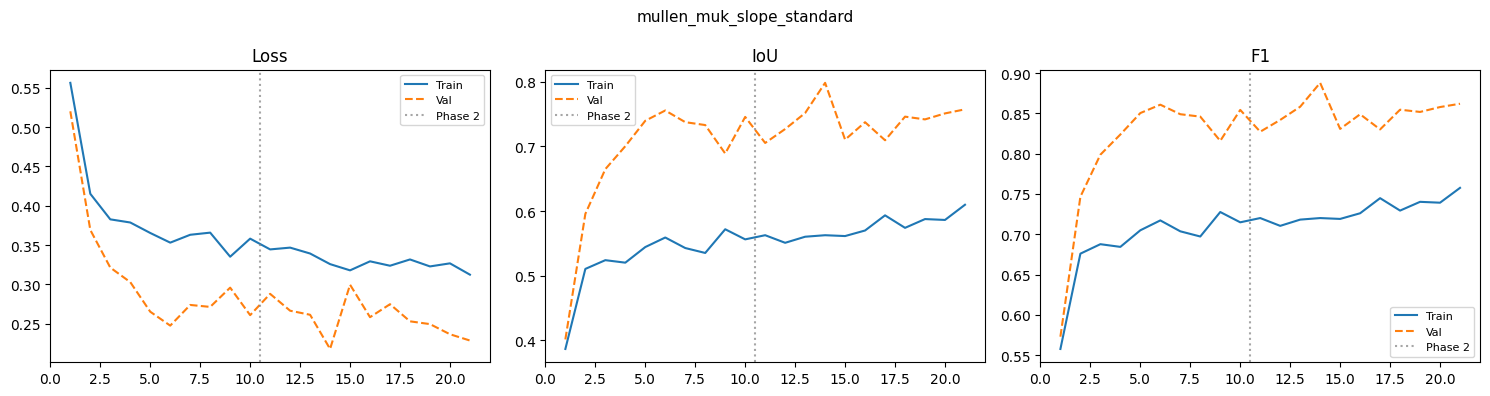

  Optimal threshold (combined): 0.444
  [local] @0.50: IoU=0.0567 F1=0.1074 P=0.0572 R=0.8799
  [local] @0.444: IoU=0.0525 F1=0.0997 P=0.0528 R=0.8890
  [mukherjee] @0.50: IoU=0.8669 F1=0.9287 P=0.9556 R=0.9032
  [mukherjee] @0.444: IoU=0.8686 F1=0.9297 P=0.9504 R=0.9098
  [combined] @0.50: IoU=0.8561 F1=0.9225 P=0.9426 R=0.9032
  [combined] @0.444: IoU=0.8569 F1=0.9229 P=0.9364 R=0.9098
  Skipping log — 'mullen_muk_slope_standard' already exists.


In [11]:
results_7 = run_experiment({
    "name":"mullen_muk_slope_standard",
    "train_sources":["mukherjee"], "use_slope":True,
    "augmentation":"standard",
    "notes":"Mukherjee only, slope, standard aug"})


  mullen_muk_slope_aggressive
  Train sources: ['mukherjee']  Slope: True  Aug: aggressive
  Train: 65 scenes  Val: 8 scenes
  Train chips: 1297  Val chips: 151
  Water fraction: 31.2%  weights: nw=0.62 w=1.38
  Stem weights transferred: 1
  Resumed from epoch 23
  Encoder unfrozen. Trainable: 67,100,082
  [p2] 24/25 tr loss=0.5523 iou=0.340 | vl loss=0.3315 iou=0.695 | lr=1.0e-05 | no_imp=7
  Early stopping at epoch 24


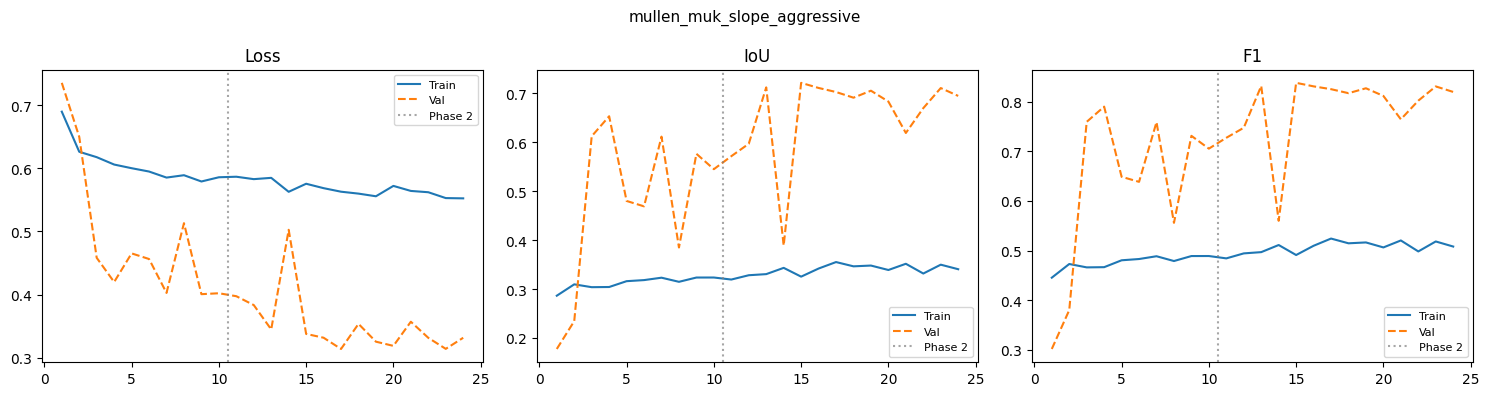

  Optimal threshold (combined): 0.629
  [local] @0.50: IoU=0.1497 F1=0.2604 P=0.1836 R=0.4480
  [local] @0.629: IoU=0.2179 F1=0.3578 P=0.3345 R=0.3846
  [mukherjee] @0.50: IoU=0.8461 F1=0.9166 P=0.9095 R=0.9238
  [mukherjee] @0.629: IoU=0.8489 F1=0.9183 P=0.9225 R=0.9141
  [combined] @0.50: IoU=0.8444 F1=0.9156 P=0.9079 R=0.9234
  [combined] @0.629: IoU=0.8480 F1=0.9177 P=0.9219 R=0.9136
  Skipping log — 'mullen_muk_slope_aggressive' already exists.


In [12]:
results_8 = run_experiment({
    "name":"mullen_muk_slope_aggressive",
    "train_sources":["mukherjee"], "use_slope":True,
    "augmentation":"aggressive",
    "notes":"Mukherjee only, slope, aggressive aug"})


  mullen_muk_noslope_standard
  Train sources: ['mukherjee']  Slope: False  Aug: standard
  Train: 65 scenes  Val: 8 scenes
  Train chips: 1297  Val chips: 151
  Water fraction: 31.3%  weights: nw=0.63 w=1.37
  Stem weights transferred: 1
  Resumed from epoch 21
  Encoder unfrozen. Trainable: 67,099,506
  [p2] 22/25 tr loss=0.3243 iou=0.605 | vl loss=0.2333 iou=0.767 | lr=1.0e-05 | no_imp=6
  Early stopping at epoch 22


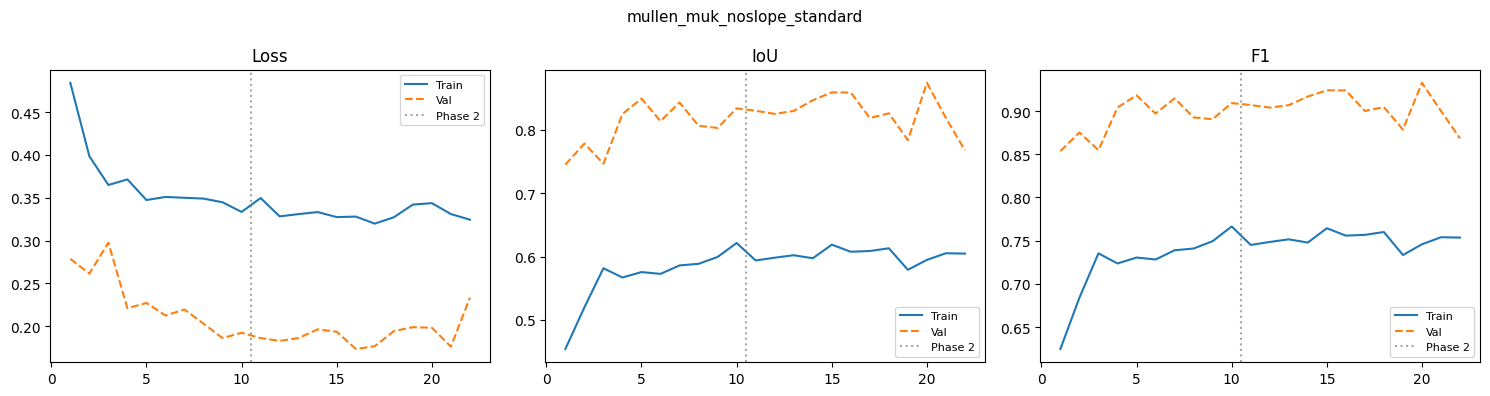

  Optimal threshold (combined): 0.239
  [local] @0.50: IoU=0.5477 F1=0.7078 P=0.7506 R=0.6696
  [local] @0.239: IoU=0.5242 F1=0.6878 P=0.6012 R=0.8036
  [mukherjee] @0.50: IoU=0.8744 F1=0.9330 P=0.9533 R=0.9135
  [mukherjee] @0.239: IoU=0.8809 F1=0.9367 P=0.9351 R=0.9383
  [combined] @0.50: IoU=0.8740 F1=0.9328 P=0.9531 R=0.9133
  [combined] @0.239: IoU=0.8805 F1=0.9364 P=0.9347 R=0.9382
  Skipping log — 'mullen_muk_noslope_standard' already exists.


In [13]:
results_9 = run_experiment({
    "name":"mullen_muk_noslope_standard",
    "train_sources":["mukherjee"], "use_slope":False,
    "augmentation":"standard",
    "notes":"Mukherjee only, no slope, standard aug"})


  mullen_muk_noslope_aggressive
  Train sources: ['mukherjee']  Slope: False  Aug: aggressive
  Train: 65 scenes  Val: 8 scenes
  Train chips: 1297  Val chips: 151
  Water fraction: 24.3%  weights: nw=0.49 w=1.51
  Stem weights transferred: 1
  Resumed from epoch 19
  Encoder unfrozen. Trainable: 67,099,506
  [p2] 20/25 tr loss=0.5736 iou=0.310 | vl loss=0.2534 iou=0.808 | lr=1.0e-05 | no_imp=6
  Early stopping at epoch 20


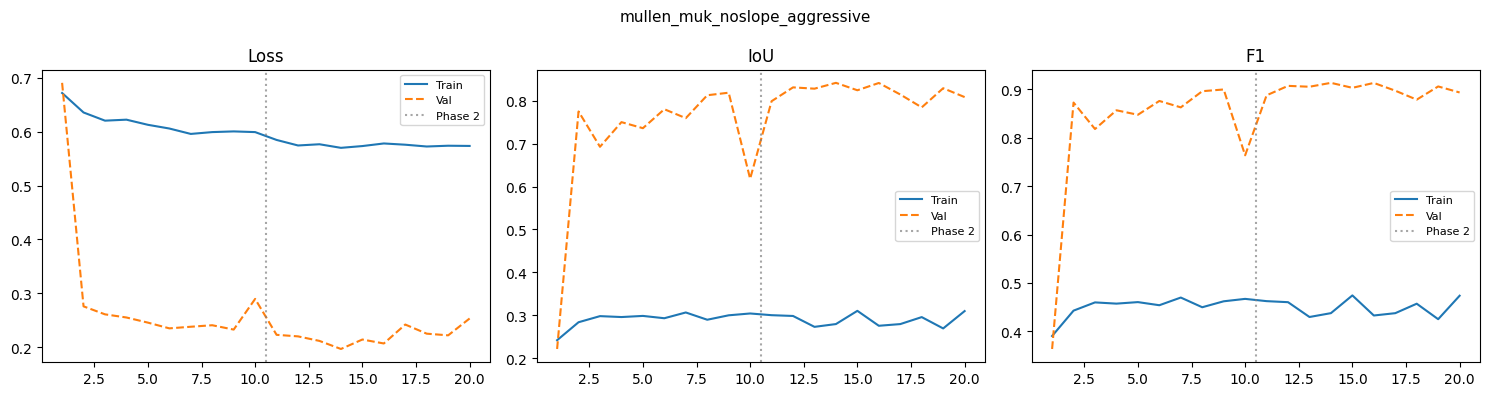

  Optimal threshold (combined): 0.391
  [local] @0.50: IoU=0.3903 F1=0.5614 P=0.9621 R=0.3964
  [local] @0.391: IoU=0.4137 F1=0.5853 P=0.9234 R=0.4284
  [mukherjee] @0.50: IoU=0.8709 F1=0.9310 P=0.9665 R=0.8980
  [mukherjee] @0.391: IoU=0.8716 F1=0.9314 P=0.9597 R=0.9047
  [combined] @0.50: IoU=0.8705 F1=0.9308 P=0.9665 R=0.8976
  [combined] @0.391: IoU=0.8712 F1=0.9312 P=0.9597 R=0.9043
  Skipping log — 'mullen_muk_noslope_aggressive' already exists.


In [14]:
results_10 = run_experiment({
    "name":"mullen_muk_noslope_aggressive",
    "train_sources":["mukherjee"], "use_slope":False,
    "augmentation":"aggressive",
    "notes":"Mukherjee only, no slope, aggressive aug"})


  mullen_muk_local_slope_standard
  Train sources: ['mukherjee', 'local']  Slope: True  Aug: standard
  Train: 71 scenes  Val: 10 scenes
  Train chips: 1393  Val chips: 183
  Water fraction: 27.2%  weights: nw=0.54 w=1.46
  Stem weights transferred: 1
  Resumed from epoch 20
  Encoder unfrozen. Trainable: 67,100,082
  [p2] 21/25 tr loss=0.3091 iou=0.600 | vl loss=0.2510 iou=0.798 | lr=1.0e-05 | no_imp=0
  [p2] 22/25 tr loss=0.3076 iou=0.592 | vl loss=0.2653 iou=0.762 | lr=1.0e-05 | no_imp=1
  [p2] 23/25 tr loss=0.3080 iou=0.602 | vl loss=0.2824 iou=0.749 | lr=1.0e-05 | no_imp=2
  [p2] 24/25 tr loss=0.3110 iou=0.598 | vl loss=0.2461 iou=0.798 | lr=1.0e-05 | no_imp=0
  [p2] 25/25 tr loss=0.3192 iou=0.575 | vl loss=0.2828 iou=0.741 | lr=1.0e-05 | no_imp=1


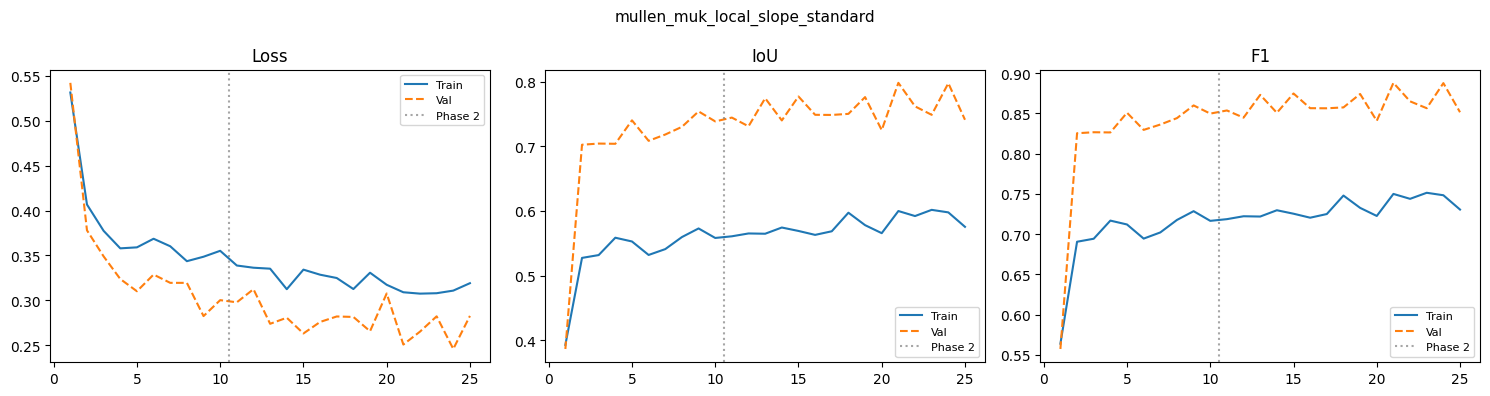

  Optimal threshold (combined): 0.321
  [local] @0.50: IoU=0.4717 F1=0.6410 P=0.5455 R=0.7771
  [local] @0.321: IoU=0.3068 F1=0.4696 P=0.3266 R=0.8356
  [mukherjee] @0.50: IoU=0.8605 F1=0.9250 P=0.9571 R=0.8950
  [mukherjee] @0.321: IoU=0.8679 F1=0.9293 P=0.9405 R=0.9184
  [combined] @0.50: IoU=0.8599 F1=0.9247 P=0.9565 R=0.8949
  [combined] @0.321: IoU=0.8667 F1=0.9286 P=0.9391 R=0.9183
  Skipping log — 'mullen_muk_local_slope_standard' already exists.


In [15]:
results_11 = run_experiment({
    "name":"mullen_muk_local_slope_standard",
    "train_sources":["mukherjee","local"], "use_slope":True,
    "augmentation":"standard",
    "notes":"Mukherjee + local, slope, standard aug"})


  mullen_muk_local_slope_aggressive
  Train sources: ['mukherjee', 'local']  Slope: True  Aug: aggressive
  Train: 71 scenes  Val: 10 scenes
  Train chips: 1393  Val chips: 183
  Water fraction: 18.7%  weights: nw=0.37 w=1.63
  Stem weights transferred: 1
  Resumed from epoch 24
  Encoder unfrozen. Trainable: 67,100,082
  [p2] 25/25 tr loss=0.5470 iou=0.354 | vl loss=0.3726 iou=0.691 | lr=1.0e-05 | no_imp=6
  Early stopping at epoch 25


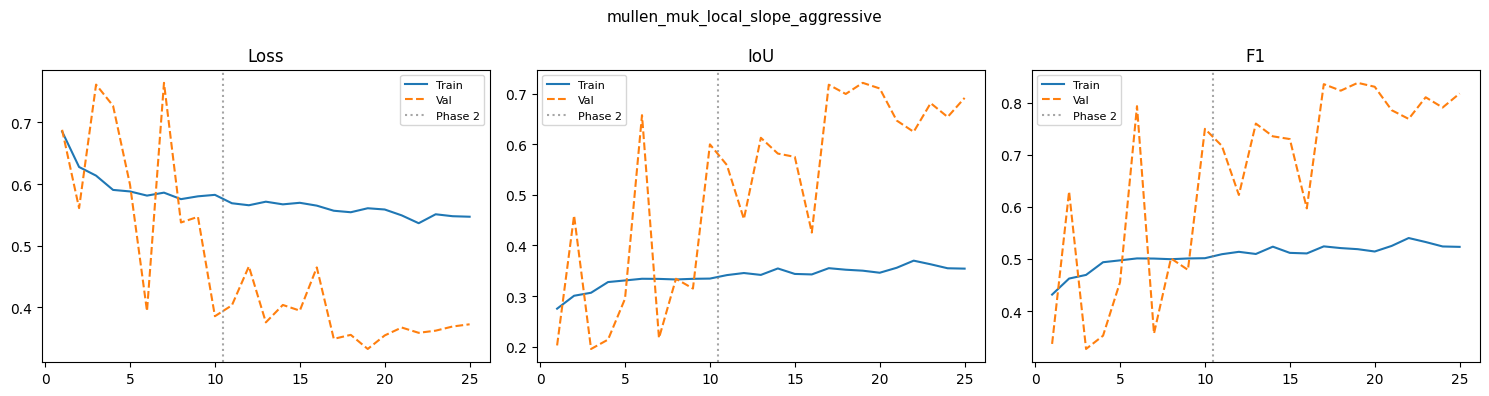

  Optimal threshold (combined): 0.446
  [local] @0.50: IoU=0.2732 F1=0.4292 P=0.2928 R=0.8036
  [local] @0.446: IoU=0.2328 F1=0.3777 P=0.2456 R=0.8174
  [mukherjee] @0.50: IoU=0.8464 F1=0.9168 P=0.9260 R=0.9078
  [mukherjee] @0.446: IoU=0.8473 F1=0.9173 P=0.9215 R=0.9132
  [combined] @0.50: IoU=0.8450 F1=0.9160 P=0.9244 R=0.9078
  [combined] @0.446: IoU=0.8455 F1=0.9163 P=0.9195 R=0.9131
  Skipping log — 'mullen_muk_local_slope_aggressive' already exists.


In [16]:
results_12 = run_experiment({
    "name":"mullen_muk_local_slope_aggressive",
    "train_sources":["mukherjee","local"], "use_slope":True,
    "augmentation":"aggressive",
    "notes":"Mukherjee + local, slope, aggressive aug"})


  mullen_muk_local_noslope_standard
  Train sources: ['mukherjee', 'local']  Slope: False  Aug: standard
  Train: 71 scenes  Val: 10 scenes
  Train chips: 1393  Val chips: 183
  Water fraction: 22.0%  weights: nw=0.44 w=1.56
  Stem weights transferred: 1
  Resumed from epoch 21
  Encoder unfrozen. Trainable: 67,099,506
  [p2] 22/25 tr loss=0.3302 iou=0.570 | vl loss=0.2266 iou=0.836 | lr=1.0e-05 | no_imp=0
  [p2] 23/25 tr loss=0.3300 iou=0.595 | vl loss=0.2750 iou=0.718 | lr=1.0e-05 | no_imp=1
  [p2] 24/25 tr loss=0.3188 iou=0.563 | vl loss=0.2368 iou=0.853 | lr=1.0e-05 | no_imp=2
  [p2] 25/25 tr loss=0.3185 iou=0.568 | vl loss=0.2247 iou=0.825 | lr=1.0e-05 | no_imp=0


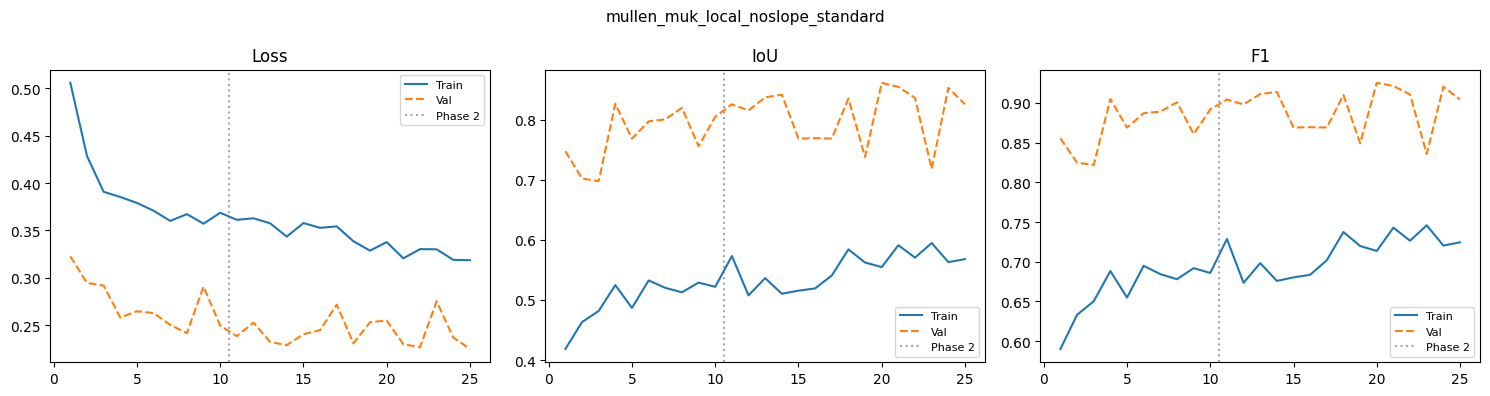

  Optimal threshold (combined): 0.457
  [local] @0.50: IoU=0.5231 F1=0.6869 P=0.5580 R=0.8933
  [local] @0.457: IoU=0.5061 F1=0.6720 P=0.5341 R=0.9059
  [mukherjee] @0.50: IoU=0.8910 F1=0.9423 P=0.9565 R=0.9286
  [mukherjee] @0.457: IoU=0.8915 F1=0.9426 P=0.9527 R=0.9327
  [combined] @0.50: IoU=0.8904 F1=0.9420 P=0.9559 R=0.9286
  [combined] @0.457: IoU=0.8909 F1=0.9423 P=0.9521 R=0.9327
  Skipping log — 'mullen_muk_local_noslope_standard' already exists.


In [17]:
results_13 = run_experiment({
    "name":"mullen_muk_local_noslope_standard",
    "train_sources":["mukherjee","local"], "use_slope":False,
    "augmentation":"standard",
    "notes":"Mukherjee + local, no slope, standard aug"})


  mullen_muk_local_noslope_aggressive
  Train sources: ['mukherjee', 'local']  Slope: False  Aug: aggressive
  Train: 71 scenes  Val: 10 scenes
  Train chips: 1393  Val chips: 183
  Water fraction: 22.4%  weights: nw=0.45 w=1.55
  Stem weights transferred: 1
  Resumed from epoch 17
  Encoder unfrozen. Trainable: 67,099,506
  [p2] 18/25 tr loss=0.5870 iou=0.309 | vl loss=0.2835 iou=0.699 | lr=1.0e-05 | no_imp=6
  Early stopping at epoch 18


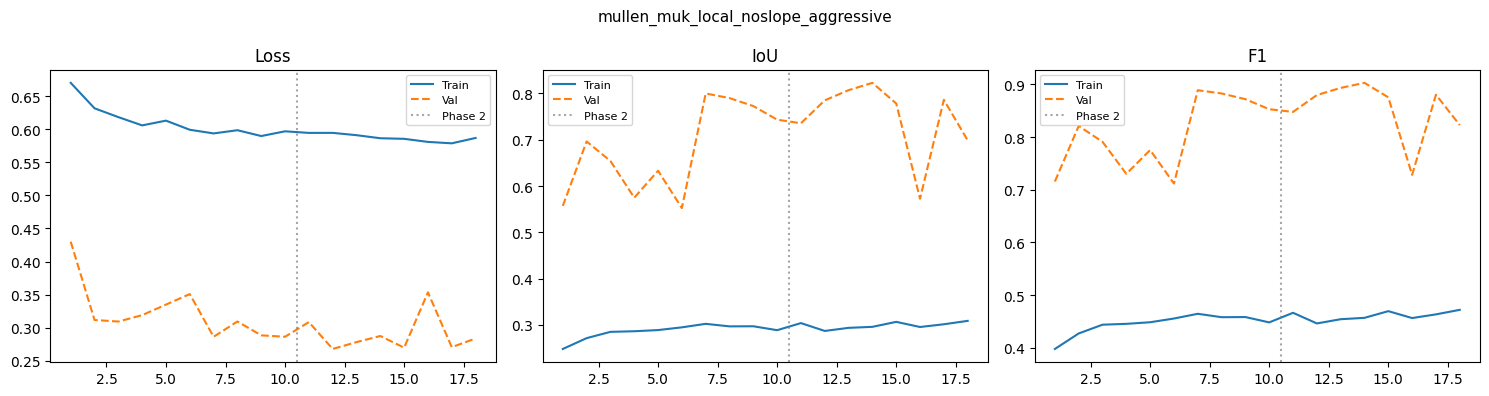

  Optimal threshold (combined): 0.711
  [local] @0.50: IoU=0.4670 F1=0.6367 P=0.8004 R=0.5286
  [local] @0.711: IoU=0.4654 F1=0.6352 P=0.9556 R=0.4757
  [mukherjee] @0.50: IoU=0.8708 F1=0.9309 P=0.9341 R=0.9278
  [mukherjee] @0.711: IoU=0.8771 F1=0.9346 P=0.9567 R=0.9134
  [combined] @0.50: IoU=0.8704 F1=0.9307 P=0.9340 R=0.9274
  [combined] @0.711: IoU=0.8768 F1=0.9343 P=0.9567 R=0.9130
  Skipping log — 'mullen_muk_local_noslope_aggressive' already exists.


In [18]:
results_14 = run_experiment({
    "name":"mullen_muk_local_noslope_aggressive",
    "train_sources":["mukherjee","local"], "use_slope":False,
    "augmentation":"aggressive",
    "notes":"Mukherjee + local, no slope, aggressive aug"})

---
## 8. Results Summary (Experiments 7–14)
Cross-experiment comparison across all 14 experiments is in `unet_shared_test_eval.ipynb`.

In [19]:
log_path = EXPERIMENTS_DIR / "experiment_log.csv"
df = pd.read_csv(log_path)

# Show F1 at both thresholds for all splits, pivoted for readability
summary = df[df["threshold"].astype(str) == "0.5"].pivot_table(
    index="name", columns="test_split",
    values=["iou","f1","precision","recall"], aggfunc="first"
)
display(summary.round(4))
print(f"Full log saved: {log_path}")

f1                        iou  \
test_split                          combined   local mukherjee combined   
name                                                                      
mullen_muk_local_noslope_aggressive   0.9307  0.6367    0.9309   0.8704   
mullen_muk_local_noslope_standard     0.9313  0.6601    0.9315   0.8714   
mullen_muk_local_slope_aggressive     0.9160  0.4292    0.9168   0.8450   
mullen_muk_local_slope_standard       0.9334  0.1765    0.9370   0.8752   
mullen_muk_noslope_aggressive         0.9308  0.5614    0.9310   0.8705   
mullen_muk_noslope_standard           0.9328  0.7078    0.9330   0.8740   
mullen_muk_slope_aggressive           0.9156  0.2604    0.9166   0.8444   
mullen_muk_slope_standard             0.9225  0.1074    0.9287   0.8561   

                                                      precision          \
test_split                            local mukherjee  combined   local   
name                                                                      
mullen_muk_local_noslope_aggressive  0.4670    0.8708    0.9340  0.8004   
mullen_muk_local_noslope_standard    0.4927    0.8718    0.9613  0.6497   
mullen_muk_local_slope_aggressive    0.2732    0.8464    0.9244  0.2928   
mullen_muk_local_slope_standard      0.0968    0.8815    0.9521  0.0978   
mullen_muk_noslope_aggressive        0.3903    0.8709    0.9665  0.9621   
mullen_muk_noslope_standard          0.5477    0.8744    0.9531  0.7506   
mullen_muk_slope_aggressive          0.1497    0.8461    0.9079  0.1836   
mullen_muk_slope_standard            0.0567    0.8669    0.9426  0.0572   

                                                recall                    
test_split                          mukherjee combined   local mukherjee  
name                                                                      
mullen_muk_local_noslope_aggressive    0.9341   0.9274  0.5286    0.9278  
mullen_muk_local_noslope_standard      0.9616   0.9031  0.6709    0.9033  
mullen_muk_local_slope_aggressive      0.9260   0.9078  0.8036    0.9078  
mullen_muk_local_slope_standard        0.9596   0.9155  0.9068    0.9155  
mullen_muk_noslope_aggressive          0.9665   0.8976  0.3964    0.8980  
mullen_muk_noslope_standard            0.9533   0.9133  0.6696    0.9135  
mullen_muk_slope_aggressive            0.9095   0.9234  0.4480    0.9238  
mullen_muk_slope_standard              0.9556   0.9032  0.8799    0.9032

Full log saved: /content/drive/MyDrive/Research/EO-Methane/paper2/experiments_mullen_muk/experiment_log.csv


In [20]:
# log_path = EXPERIMENTS_DIR / "experiment_log.csv"
# df = pd.read_csv(log_path)

# Show F1 at both thresholds for all splits, pivoted for readability
summary2 = df[df["threshold"].astype(str) != "0.5"].pivot_table(
    index="name", columns="test_split",
    values=["threshold", "iou","f1","precision","recall"], aggfunc="first"
)
display(summary2.round(4))
# print(f"Full log saved: {log_path}")

f1                        iou  \
test_split                          combined   local mukherjee combined   
name                                                                      
mullen_muk_local_noslope_aggressive   0.9343  0.6352    0.9346   0.8768   
mullen_muk_local_noslope_standard     0.9353  0.6837    0.9356   0.8785   
mullen_muk_local_slope_aggressive     0.9163  0.3777    0.9173   0.8455   
mullen_muk_local_slope_standard       0.9337  0.1631    0.9376   0.8756   
mullen_muk_noslope_aggressive         0.9312  0.5853    0.9314   0.8712   
mullen_muk_noslope_standard           0.9364  0.6878    0.9367   0.8805   
mullen_muk_slope_aggressive           0.9177  0.3578    0.9183   0.8480   
mullen_muk_slope_standard             0.9229  0.0997    0.9297   0.8569   

                                                      precision          \
test_split                            local mukherjee  combined   local   
name                                                                      
mullen_muk_local_noslope_aggressive  0.4654    0.8771    0.9567  0.9556   
mullen_muk_local_noslope_standard    0.5194    0.8790    0.9448  0.6001   
mullen_muk_local_slope_aggressive    0.2328    0.8473    0.9195  0.2456   
mullen_muk_local_slope_standard      0.0888    0.8826    0.9475  0.0896   
mullen_muk_noslope_aggressive        0.4137    0.8716    0.9597  0.9234   
mullen_muk_noslope_standard          0.5242    0.8809    0.9347  0.6012   
mullen_muk_slope_aggressive          0.2179    0.8489    0.9219  0.3345   
mullen_muk_slope_standard            0.0525    0.8686    0.9364  0.0528   

                                                recall                    \
test_split                          mukherjee combined   local mukherjee   
name                                                                       
mullen_muk_local_noslope_aggressive    0.9567   0.9130  0.4757    0.9134   
mullen_muk_local_noslope_standard      0.9453   0.9260  0.7944    0.9261   
mullen_muk_local_slope_aggressive      0.9215   0.9131  0.8174    0.9132   
mullen_muk_local_slope_standard        0.9556   0.9202  0.9107    0.9203   
mullen_muk_noslope_aggressive          0.9597   0.9043  0.4284    0.9047   
mullen_muk_noslope_standard            0.9351   0.9382  0.8036    0.9383   
mullen_muk_slope_aggressive            0.9225   0.9136  0.3846    0.9141   
mullen_muk_slope_standard              0.9504   0.9098  0.8890    0.9098   

                                    threshold                   
test_split                           combined  local mukherjee  
name                                                            
mullen_muk_local_noslope_aggressive     0.711  0.711     0.711  
mullen_muk_local_noslope_standard       0.308  0.308     0.308  
mullen_muk_local_slope_aggressive       0.446  0.446     0.446  
mullen_muk_local_slope_standard         0.459  0.459     0.459  
mullen_muk_noslope_aggressive           0.391  0.391     0.391  
mullen_muk_noslope_standard             0.239  0.239     0.239  
mullen_muk_slope_aggressive             0.629  0.629     0.629  
mullen_muk_slope_standard               0.444  0.444     0.444

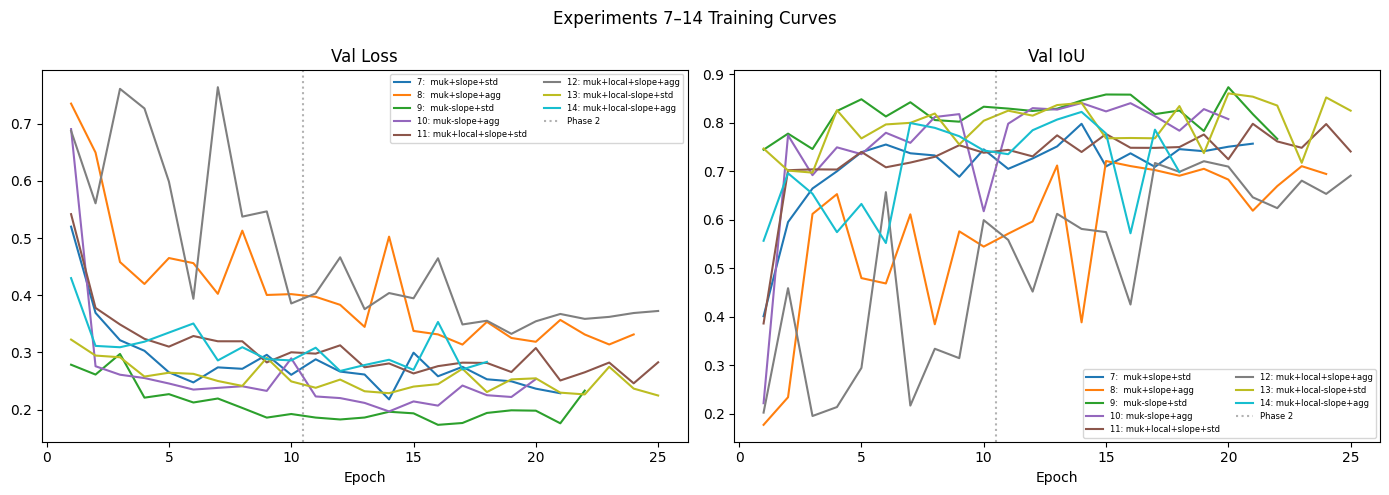

In [21]:
# ── Val IoU overlay — all 8 experiments ──────────────────────────────────────
all_results = [
    (results_7,  "7:  muk+slope+std"),
    (results_8,  "8:  muk+slope+agg"),
    (results_9,  "9:  muk-slope+std"),
    (results_10, "10: muk-slope+agg"),
    (results_11, "11: muk+local+slope+std"),
    (results_12, "12: muk+local+slope+agg"),
    (results_13, "13: muk+local-slope+std"),
    (results_14, "14: muk+local-slope+agg"),
]
cmap_8 = plt.cm.get_cmap("tab10", 8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (res, label) in enumerate(all_results):
    h  = res["history"]
    ep = range(1, len(h["val_loss"])+1)
    c  = cmap_8(i)
    axes[0].plot(ep, h["val_loss"], label=label, color=c)
    axes[1].plot(ep, h["val_iou"],  label=label, color=c)

for ax, title in zip(axes, ["Val Loss", "Val IoU"]):
    ax.axvline(x=PHASE1_EPOCHS+0.5, color="grey", linestyle=":",
               alpha=0.6, label="Phase 2")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(fontsize=6, ncol=2)

plt.suptitle("Experiments 7–14 Training Curves", fontsize=12)
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR/"val_curves_7_14.png", dpi=150)
plt.show()